# Предсказание RON и MON: расширенный бенчмарк моделей и фичей

В этом ноутбуке:
- используем **тот же split**, что и в `seminar.ipynb`: `train_test_split(test_size=0.2, random_state=42)`;
- добавляем модели **NuSVR**, **Extra Trees**, **LightGBM**, **Stacking**;
- исследуем дополнительные фичи без отдельного feature selection;
- сравниваем, какие комбинации признаков лучше работают для **RON** и **MON**;
- в конце отдельно донастраиваем лучшие конфигурации через **Optuna**.

## 1. Импорты и настройки

In [17]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["MPLCONFIGDIR"] = "/tmp/mplcfg"

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import shap

from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    Fragments,
    GraphDescriptors,
    Lipinski,
    MolSurf,
    rdFingerprintGenerator,
)

from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import NuSVR

from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_PATH = "data.csv"
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Загрузка данных и фиксированный split

In [18]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df_clean = df.dropna(subset=["RON", "MON"]).reset_index(drop=True)

base_features = [
    "P", "S", "T", "Q+Qr", "P*", "S*", "T*", "Sr", "Tr", "OH",
    "Bz", "Opos", "Dbc", "Br", "DD", "SCpos", "C=O", "O", "COO", "nBP",
]

all_idx = np.arange(len(df_clean))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("Rows after dropna(['RON', 'MON']):", len(df_clean))
print("Base feature count:", len(base_features))
df_clean[["Name", "FuelClass", "RON", "MON"]].head()

Rows after dropna(['RON', 'MON']): 249
Base feature count: 20


,Name,FuelClass,RON,MON
0,Ethane,Alkanes,111.0,100.7
1,Propane,Alkanes,112.5,97.1
2,n-Butane,Alkanes,93.6,90.1
3,n-Pentane,Alkanes,61.7,61.9
4,n-Hexane,Alkanes,24.8,26.0


## 3. Какие дополнительные фичи пробуем

Без feature selection пробуем такие блоки признаков:

1. **`base`**: исходные структурные табличные признаки из `data.csv`
2. **`FuelClass`**: one-hot кодирование класса топлива
3. **`extra RDKit`**:
   - физхимические дескрипторы (`MolWt`, `MolLogP`, `TPSA`, `ExactMolWt`)
   - плотности Morgan-фингерпринтов (`FpDensityMorgan1/2/3`)
   - кольцевые/гетероатомные признаки
   - topological индексы (`Chi*`, `Kappa*`, `HallKierAlpha`)
   - surface/VSA признаки
   - фрагментные счётчики (`fr_benzene`, `fr_ether`, `fr_ketone`, ...)
4. **`atom pair fingerprint`**: компактный структурный отпечаток на 256 бит

In [19]:
EXTRA_DESCRIPTOR_FUNCS = {
    "ExactMolWt": Descriptors.ExactMolWt,
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "FpDensityMorgan1": Descriptors.FpDensityMorgan1,
    "FpDensityMorgan2": Descriptors.FpDensityMorgan2,
    "FpDensityMorgan3": Descriptors.FpDensityMorgan3,
    "NHOHCount": Lipinski.NHOHCount,
    "NOCount": Lipinski.NOCount,
    "NumHeteroatoms": Lipinski.NumHeteroatoms,
    "NumSaturatedRings": Lipinski.NumSaturatedRings,
    "NumSaturatedCarbocycles": Lipinski.NumSaturatedCarbocycles,
    "NumSaturatedHeterocycles": Lipinski.NumSaturatedHeterocycles,
    "NumAromaticCarbocycles": Lipinski.NumAromaticCarbocycles,
    "NumAromaticHeterocycles": Lipinski.NumAromaticHeterocycles,
    "NumAliphaticCarbocycles": Lipinski.NumAliphaticCarbocycles,
    "NumAliphaticHeterocycles": Lipinski.NumAliphaticHeterocycles,
    "Chi0n": GraphDescriptors.Chi0n,
    "Chi1n": GraphDescriptors.Chi1n,
    "Chi2n": GraphDescriptors.Chi2n,
    "Chi3n": GraphDescriptors.Chi3n,
    "HallKierAlpha": GraphDescriptors.HallKierAlpha,
    "Kappa1": GraphDescriptors.Kappa1,
    "Kappa2": GraphDescriptors.Kappa2,
    "Kappa3": GraphDescriptors.Kappa3,
    "LabuteASA": MolSurf.LabuteASA,
    "PEOE_VSA1": MolSurf.PEOE_VSA1,
    "PEOE_VSA2": MolSurf.PEOE_VSA2,
    "PEOE_VSA3": MolSurf.PEOE_VSA3,
    "SMR_VSA1": MolSurf.SMR_VSA1,
    "SMR_VSA2": MolSurf.SMR_VSA2,
    "SlogP_VSA1": MolSurf.SlogP_VSA1,
    "SlogP_VSA2": MolSurf.SlogP_VSA2,
}

for name in [
    "fr_Al_OH", "fr_Ar_OH", "fr_COO", "fr_ketone", "fr_ether",
    "fr_benzene", "fr_phenol", "fr_aldehyde", "fr_ester",
]:
    if hasattr(Fragments, name):
        EXTRA_DESCRIPTOR_FUNCS[name] = getattr(Fragments, name)


def compute_extra_descriptors(smiles_series: pd.Series) -> pd.DataFrame:
    rows = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        rows.append({name: func(mol) for name, func in EXTRA_DESCRIPTOR_FUNCS.items()})
    return pd.DataFrame(rows)


def compute_atom_pair_fp(smiles_series: pd.Series, n_bits: int = 256) -> pd.DataFrame:
    generator = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=n_bits)
    fps = [generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi)) for smi in smiles_series]
    return pd.DataFrame(fps, columns=[f"atom_pair_{i}" for i in range(n_bits)])


extra_df = compute_extra_descriptors(df_clean["Smiles"])
atom_pair_df = compute_atom_pair_fp(df_clean["Smiles"], n_bits=256)
fuelclass_df = pd.get_dummies(df_clean["FuelClass"], prefix="FuelClass", dtype=int)

feature_sets = {
    "base": df_clean[base_features].copy(),
    "base+fuelclass": pd.concat([df_clean[base_features], fuelclass_df], axis=1),
    "base+extra": pd.concat([df_clean[base_features], extra_df], axis=1),
    "base+extra+fuelclass": pd.concat([df_clean[base_features], extra_df, fuelclass_df], axis=1),
    "base+extra+atompair": pd.concat([df_clean[base_features], extra_df, atom_pair_df], axis=1),
    "base+extra+atompair+fuelclass": pd.concat([df_clean[base_features], extra_df, atom_pair_df, fuelclass_df], axis=1),
}

pd.Series({name: X.shape[1] for name, X in feature_sets.items()}, name="n_features").to_frame()

,n_features
base,20
base+fuelclass,29
base+extra,62
base+extra+fuelclass,71
base+extra+atompair,318
base+extra+atompair+fuelclass,327


## 4. Модели для сравнения

In [20]:
DEFAULT_MODEL_PARAMS = {
    "CatBoost": {
        "iterations": 1200,
        "depth": 6,
        "learning_rate": 0.03,
        "loss_function": "RMSE",
        "verbose": 0,
        "random_state": RANDOM_STATE,
    },
    "ExtraTrees": {
        "n_estimators": 800,
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    },
    "LightGBM": {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": RANDOM_STATE,
        "verbose": -1,
        "n_jobs": 1,
    },
    "NuSVR": {
        "C": 20.0,
        "nu": 0.35,
        "kernel": "rbf",
        "gamma": "scale",
    },
}


def build_model(model_name: str, overrides: dict | None = None):
    params = dict(DEFAULT_MODEL_PARAMS[model_name])
    if overrides:
        params.update(overrides)

    if model_name == "CatBoost":
        return CatBoostRegressor(**params)
    if model_name == "ExtraTrees":
        return ExtraTreesRegressor(**params)
    if model_name == "LightGBM":
        return LGBMRegressor(**params)
    if model_name == "NuSVR":
        return Pipeline([("scaler", StandardScaler()), ("model", NuSVR(**params))])
    raise ValueError(model_name)


def build_stacking_model(
    catboost_overrides: dict | None = None,
    extratrees_overrides: dict | None = None,
    lightgbm_overrides: dict | None = None,
    ridge_alpha: float = 1.0,
):
    estimators = [
        ("extratrees", build_model("ExtraTrees", extratrees_overrides)),
        ("lightgbm", build_model("LightGBM", lightgbm_overrides)),
        ("catboost", build_model("CatBoost", catboost_overrides)),
    ]
    return StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=ridge_alpha),
        cv=3,
        n_jobs=1,
    )


MODEL_NAMES = ["CatBoost", "ExtraTrees", "LightGBM", "NuSVR"]
MODEL_NAMES

['CatBoost', 'ExtraTrees', 'LightGBM', 'NuSVR']

## 5. Функция оценки на test

In [21]:
def evaluate_feature_set(X: pd.DataFrame, y: pd.Series, target_name: str, feature_name: str) -> tuple[list[dict], dict]:
    X = X.fillna(0)
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    rows = []
    fitted_models = {}

    for model_name in MODEL_NAMES:
        model = build_model(model_name)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rows.append(
            {
                "target": target_name,
                "features": feature_name,
                "model": model_name,
                "MAE": mean_absolute_error(y_test, pred),
                "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                "R2": r2_score(y_test, pred),
            }
        )
        fitted_models[model_name] = model

    stacking = build_stacking_model()
    stacking.fit(X_train, y_train)
    pred = stacking.predict(X_test)
    rows.append(
        {
            "target": target_name,
            "features": feature_name,
            "model": "Stacking",
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        }
    )
    fitted_models["Stacking"] = stacking

    context = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "models": fitted_models,
    }
    return rows, context

## 6. Бенчмарк: модели × фичсеты

In [22]:
all_rows = []
contexts = {}

for target_name in ["RON", "MON"]:
    y = df_clean[target_name]
    for feature_name, X in feature_sets.items():
        rows, context = evaluate_feature_set(X, y, target_name, feature_name)
        all_rows.extend(rows)
        contexts[(target_name, feature_name)] = context

results_df = pd.DataFrame(all_rows).sort_values(["target", "R2", "MAE"], ascending=[True, False, True]).reset_index(drop=True)
results_df.head(20)

,target,features,model,MAE,RMSE,R2
0,MON,base+fuelclass,Stacking,4.095777,5.308440,0.899606
1,MON,base,Stacking,4.095764,5.432096,0.894874
2,MON,base+fuelclass,CatBoost,4.066224,5.519380,0.891469
3,MON,base,CatBoost,4.094429,5.583488,0.888933
4,MON,base+extra+atompair+fuelclass,Stacking,4.388027,5.631519,0.887014
5,MON,base+extra+atompair+fuelclass,CatBoost,4.246940,5.811727,0.879667
6,MON,base+extra+fuelclass,CatBoost,4.349552,5.826737,0.879045
7,MON,base+extra+fuelclass,Stacking,4.286613,5.955597,0.873636
8,MON,base+extra+atompair,CatBoost,4.440389,5.994965,0.871959
9,MON,base+extra+atompair,Stacking,4.746637,6.030296,0.870446


## 7. Лучшие результаты по таргетам

In [23]:
top_ron = results_df[results_df["target"] == "RON"].sort_values(["R2", "MAE"], ascending=[False, True]).head(12)
top_mon = results_df[results_df["target"] == "MON"].sort_values(["R2", "MAE"], ascending=[False, True]).head(12)

print("RON")
display(top_ron)
print("MON")
display(top_mon)

RON


,target,features,model,MAE,RMSE,R2
30,RON,base+extra+atompair+fuelclass,Stacking,4.080135,5.134701,0.936714
31,RON,base+extra+atompair,Stacking,4.148816,5.275363,0.933200
32,RON,base+fuelclass,Stacking,4.376193,5.689769,0.922292
33,RON,base+extra+atompair+fuelclass,CatBoost,4.547503,5.874878,0.917154
34,RON,base+fuelclass,CatBoost,4.578052,5.970540,0.914434
35,RON,base+extra+atompair,CatBoost,4.623297,6.004068,0.913470
36,RON,base+extra+fuelclass,Stacking,4.736544,6.262655,0.905856
37,RON,base,Stacking,4.644591,6.303685,0.904619
38,RON,base,CatBoost,4.785498,6.389436,0.902006
39,RON,base+extra,Stacking,4.876270,6.390910,0.901961


MON


,target,features,model,MAE,RMSE,R2
0,MON,base+fuelclass,Stacking,4.095777,5.308440,0.899606
1,MON,base,Stacking,4.095764,5.432096,0.894874
2,MON,base+fuelclass,CatBoost,4.066224,5.519380,0.891469
3,MON,base,CatBoost,4.094429,5.583488,0.888933
4,MON,base+extra+atompair+fuelclass,Stacking,4.388027,5.631519,0.887014
5,MON,base+extra+atompair+fuelclass,CatBoost,4.246940,5.811727,0.879667
6,MON,base+extra+fuelclass,CatBoost,4.349552,5.826737,0.879045
7,MON,base+extra+fuelclass,Stacking,4.286613,5.955597,0.873636
8,MON,base+extra+atompair,CatBoost,4.440389,5.994965,0.871959
9,MON,base+extra+atompair,Stacking,4.746637,6.030296,0.870446


In [24]:
best_by_feature = (
    results_df.sort_values(["target", "features", "R2", "MAE"], ascending=[True, True, False, True])
    .groupby(["target", "features"], as_index=False)
    .first()
)
best_by_feature

,target,features,model,MAE,RMSE,R2
0,MON,base,Stacking,4.095764,5.432096,0.894874
1,MON,base+extra,Stacking,4.493426,6.048875,0.869646
2,MON,base+extra+atompair,CatBoost,4.440389,5.994965,0.871959
3,MON,base+extra+atompair+fuelclass,Stacking,4.388027,5.631519,0.887014
4,MON,base+extra+fuelclass,CatBoost,4.349552,5.826737,0.879045
5,MON,base+fuelclass,Stacking,4.095777,5.308440,0.899606
6,RON,base,Stacking,4.644591,6.303685,0.904619
7,RON,base+extra,Stacking,4.876270,6.390910,0.901961
8,RON,base+extra+atompair,Stacking,4.148816,5.275363,0.933200
9,RON,base+extra+atompair+fuelclass,Stacking,4.080135,5.134701,0.936714


## 8. Визуализация: R² по моделям для лучших фичсетов

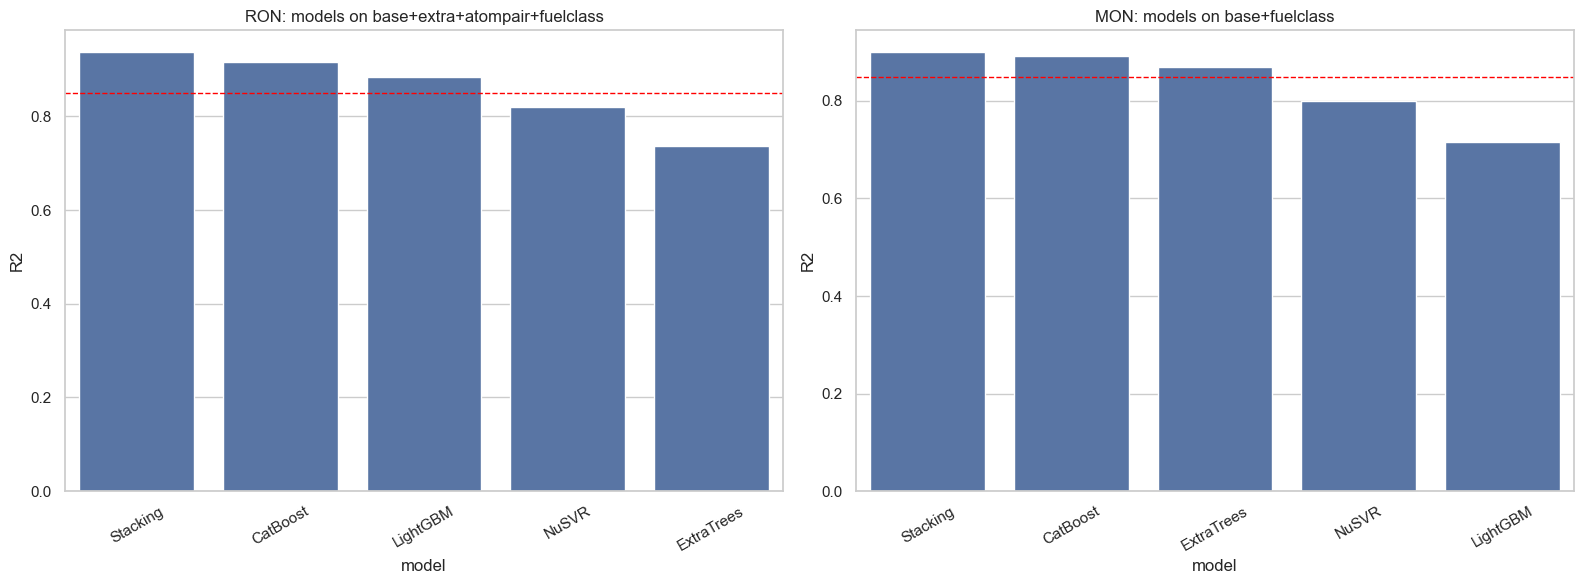

In [25]:
best_ron_feature = top_ron.iloc[0]["features"]
best_mon_feature = top_mon.iloc[0]["features"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=results_df[(results_df["target"] == "RON") & (results_df["features"] == best_ron_feature)],
    x="model",
    y="R2",
    ax=axes[0],
)
axes[0].set_title(f"RON: models on {best_ron_feature}")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(0.85, color="red", linestyle="--", linewidth=1)

sns.barplot(
    data=results_df[(results_df["target"] == "MON") & (results_df["features"] == best_mon_feature)],
    x="model",
    y="R2",
    ax=axes[1],
)
axes[1].set_title(f"MON: models on {best_mon_feature}")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(0.85, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## 9. Train-Only CV summary

Ниже считаем `CV` только на train-части.

Это нужно для двух вещей:
- показать не только hold-out test, но и устойчивость по фолдам;
- выбрать фичсет для `Optuna` без использования test-метрик.

In [26]:
CV_SUMMARY = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def compute_cv_summary_for_target(target_name: str) -> tuple[pd.DataFrame, str]:
    y = df_clean[target_name]
    rows = []
    for feature_name, X in feature_sets.items():
        X_train = X.fillna(0).iloc[train_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)

        candidate_models = {
            "CatBoost": build_model("CatBoost"),
            "ExtraTrees": build_model("ExtraTrees"),
            "LightGBM": build_model("LightGBM"),
            "NuSVR": build_model("NuSVR"),
            "Stacking": build_stacking_model(),
        }

        for model_name, model in candidate_models.items():
            mae_scores = -cross_val_score(
                model,
                X_train,
                y_train,
                cv=CV_SUMMARY,
                scoring="neg_mean_absolute_error",
                n_jobs=1,
            )
            r2_scores = cross_val_score(
                model,
                X_train,
                y_train,
                cv=CV_SUMMARY,
                scoring="r2",
                n_jobs=1,
            )
            rows.append(
                {
                    "target": target_name,
                    "features": feature_name,
                    "model": model_name,
                    "cv_mae_mean": mae_scores.mean(),
                    "cv_mae_std": mae_scores.std(),
                    "cv_r2_mean": r2_scores.mean(),
                    "cv_r2_std": r2_scores.std(),
                }
            )

    cv_df = pd.DataFrame(rows).sort_values(["model", "cv_mae_mean"])
    best_stacking_feature = (
        cv_df[cv_df["model"] == "Stacking"]
        .sort_values("cv_mae_mean", ascending=True)
        .iloc[0]["features"]
    )
    return cv_df, best_stacking_feature


cv_ron_df, best_ron_stacking_feature = compute_cv_summary_for_target("RON")
cv_mon_df, best_mon_stacking_feature = compute_cv_summary_for_target("MON")

print("RON best stacking feature by train-only CV:", best_ron_stacking_feature)
display(cv_ron_df.sort_values(["cv_mae_mean"]).head(12))

print("MON best stacking feature by train-only CV:", best_mon_stacking_feature)
display(cv_mon_df.sort_values(["cv_mae_mean"]).head(12))

RON best stacking feature by train-only CV: base+extra+fuelclass


,target,features,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
19,RON,base+extra+fuelclass,Stacking,5.551192,1.279303,0.851224,0.029178
15,RON,base+extra+fuelclass,CatBoost,5.570721,1.169741,0.868108,0.026782
10,RON,base+extra,CatBoost,5.610764,1.285202,0.866331,0.032747
5,RON,base+fuelclass,CatBoost,5.682262,1.600925,0.862648,0.048419
25,RON,base+extra+atompair+fuelclass,CatBoost,5.803636,0.816660,0.863279,0.031109
20,RON,base+extra+atompair,CatBoost,5.806036,0.739033,0.857233,0.037459
14,RON,base+extra,Stacking,5.840300,1.423756,0.837757,0.036286
29,RON,base+extra+atompair+fuelclass,Stacking,5.841642,0.714698,0.863787,0.052694
9,RON,base+fuelclass,Stacking,5.853999,1.390813,0.850520,0.046208
16,RON,base+extra+fuelclass,ExtraTrees,5.947207,1.709270,0.836688,0.046686


MON best stacking feature by train-only CV: base+extra+atompair+fuelclass


,target,features,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
5,MON,base+fuelclass,CatBoost,5.238989,1.645343,0.835318,0.052806
29,MON,base+extra+atompair+fuelclass,Stacking,5.298913,0.914090,0.841838,0.034081
19,MON,base+extra+fuelclass,Stacking,5.458231,1.999823,0.822954,0.086072
9,MON,base+fuelclass,Stacking,5.470356,1.549999,0.818517,0.051838
24,MON,base+extra+atompair,Stacking,5.470511,1.053954,0.832911,0.043985
15,MON,base+extra+fuelclass,CatBoost,5.486643,1.490651,0.834785,0.042308
25,MON,base+extra+atompair+fuelclass,CatBoost,5.517962,1.102306,0.829806,0.024359
3,MON,base,NuSVR,5.518124,1.348952,0.813217,0.048473
20,MON,base+extra+atompair,CatBoost,5.543176,1.184339,0.827991,0.028623
16,MON,base+extra+fuelclass,ExtraTrees,5.596453,2.186425,0.816840,0.088627


## 10. Диагностика лучших моделей

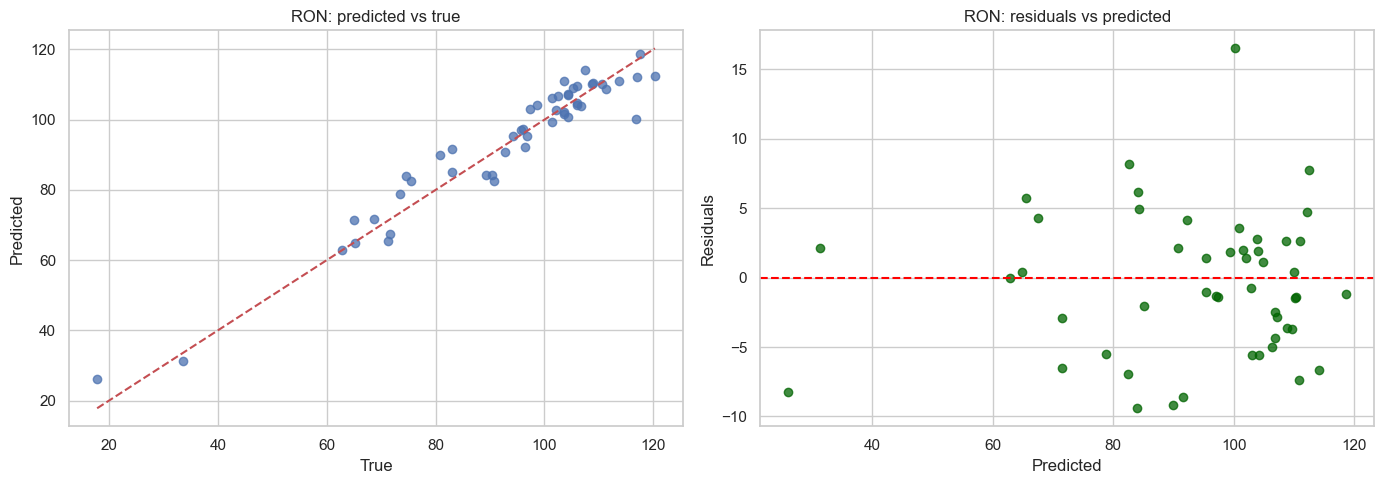

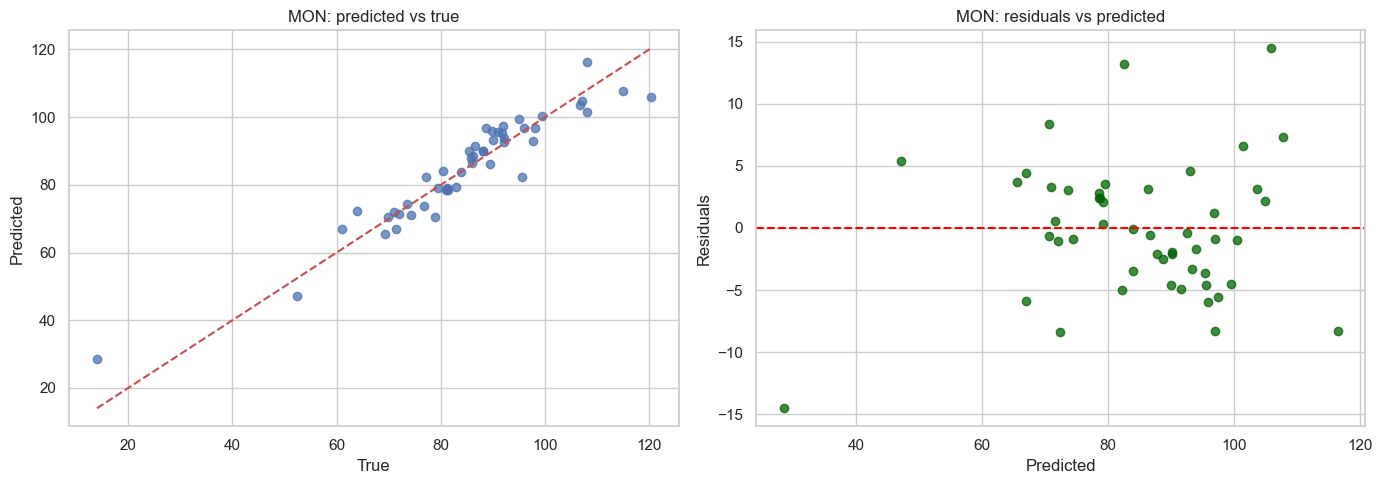

,target,features,model,R2,MAE,RMSE
0,RON,base+extra+atompair+fuelclass,Stacking,0.936714,4.080135,5.134701
1,MON,base+fuelclass,Stacking,0.899606,4.095777,5.308440


In [27]:
def refit_and_plot(best_row: pd.Series):
    target_name = best_row["target"]
    feature_name = best_row["features"]
    model_name = best_row["model"]

    X = feature_sets[feature_name].fillna(0)
    y = df_clean[target_name]

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    if model_name == "Stacking":
        model = build_stacking_model()
    else:
        model = build_model(model_name)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    residuals = y_test - pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, pred, alpha=0.75)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[0].set_title(f"{target_name}: predicted vs true")
    axes[0].set_xlabel("True")
    axes[0].set_ylabel("Predicted")

    axes[1].scatter(pred, residuals, alpha=0.75, color="darkgreen")
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_title(f"{target_name}: residuals vs predicted")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()

    return {
        "target": target_name,
        "features": feature_name,
        "model": model_name,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    }


best_ron_row = top_ron.iloc[0]
best_mon_row = top_mon.iloc[0]

ron_diag = refit_and_plot(best_ron_row)
mon_diag = refit_and_plot(best_mon_row)

pd.DataFrame([ron_diag, mon_diag])

## 11. Optuna для лучших конфигураций

Ниже донастраиваем базовые модели `CatBoost`, `ExtraTrees`, `LightGBM` для лучшего stacking-фичсета каждого таргета.

- objective использует только **train** часть лучшего фичсета;
- лучший фичсет для stacking выбирается по **train-only CV**, а не по test;
- оптимизируем **MAE** по `KFold` на train-only;
- после этого сравниваем:
  - нетюненные базовые модели,
  - тюненные базовые модели,
  - stacking из нетюненных,
  - stacking из тюненных.

In [28]:
OPTUNA_TRIALS = 15
OPTUNA_CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_optuna_model(trial: optuna.Trial, model_name: str):
    if model_name == "CatBoost":
        return build_model(
            "CatBoost",
            {
                "iterations": trial.suggest_int("iterations", 500, 1600, step=100),
                "depth": trial.suggest_int("depth", 4, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 8.0),
            },
        )

    if model_name == "ExtraTrees":
        return build_model(
            "ExtraTrees",
            {
                "n_estimators": trial.suggest_int("n_estimators", 300, 1000, step=100),
                "max_depth": trial.suggest_int("max_depth", 6, 18),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            },
        )

    if model_name == "LightGBM":
        return build_model(
            "LightGBM",
            {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 15, 63),
                "subsample": trial.suggest_float("subsample", 0.7, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            },
        )

    if model_name == "NuSVR":
        return build_model(
            "NuSVR",
            {
                "C": trial.suggest_float("C", 1.0, 50.0, log=True),
                "nu": trial.suggest_float("nu", 0.2, 0.8),
                "gamma": trial.suggest_float("gamma", 1e-3, 1.0, log=True),
            },
        )

    raise ValueError(model_name)


def tune_base_models_for_target(target_name: str, feature_name: str):
    X = feature_sets[feature_name].fillna(0)
    y = df_clean[target_name]
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    studies = {}
    tuned_params = {}
    for model_name in ["CatBoost", "ExtraTrees", "LightGBM"]:
        def objective(trial: optuna.Trial) -> float:
            model = build_optuna_model(trial, model_name)
            mae_scores = cross_val_score(
                model,
                X_train,
                y_train,
                cv=OPTUNA_CV,
                scoring="neg_mean_absolute_error",
                n_jobs=1,
            )
            return -mae_scores.mean()

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
        studies[model_name] = study
        tuned_params[model_name] = study.best_params

    untuned_models = {
        "CatBoost": build_model("CatBoost"),
        "ExtraTrees": build_model("ExtraTrees"),
        "LightGBM": build_model("LightGBM"),
    }
    tuned_models = {
        name: build_optuna_model(optuna.trial.FixedTrial(params), name)
        for name, params in tuned_params.items()
    }

    rows = []
    for model_group, models in [("untuned", untuned_models), ("tuned", tuned_models)]:
        for model_name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            rows.append(
                {
                    "target": target_name,
                    "features": feature_name,
                    "model": model_name,
                    "stage": model_group,
                    "MAE": mean_absolute_error(y_test, pred),
                    "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                    "R2": r2_score(y_test, pred),
                }
            )

    stacking_untuned = StackingRegressor(
        estimators=[
            ("extratrees", untuned_models["ExtraTrees"]),
            ("lightgbm", untuned_models["LightGBM"]),
            ("catboost", untuned_models["CatBoost"]),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=3,
        n_jobs=1,
    )
    stacking_tuned = StackingRegressor(
        estimators=[
            ("extratrees", tuned_models["ExtraTrees"]),
            ("lightgbm", tuned_models["LightGBM"]),
            ("catboost", tuned_models["CatBoost"]),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=3,
        n_jobs=1,
    )

    for label, model in [("untuned", stacking_untuned), ("tuned", stacking_tuned)]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rows.append(
            {
                "target": target_name,
                "features": feature_name,
                "model": "Stacking",
                "stage": label,
                "MAE": mean_absolute_error(y_test, pred),
                "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                "R2": r2_score(y_test, pred),
            }
        )

    return pd.DataFrame(rows), studies

ron_optuna_cmp, ron_studies = tune_base_models_for_target("RON", best_ron_stacking_feature)
mon_optuna_cmp, mon_studies = tune_base_models_for_target("MON", best_mon_stacking_feature)

optuna_results = pd.concat([ron_optuna_cmp, mon_optuna_cmp], ignore_index=True)
display(optuna_results)

print("RON best params:")
for name, study in ron_studies.items():
    print(name, study.best_params)

print()
print("MON best params:")
for name, study in mon_studies.items():
    print(name, study.best_params)

,target,features,model,stage,MAE,RMSE,R2
0,RON,base+extra+fuelclass,CatBoost,untuned,4.657686,6.482567,0.899128
1,RON,base+extra+fuelclass,ExtraTrees,untuned,5.019744,6.689238,0.892594
2,RON,base+extra+fuelclass,LightGBM,untuned,5.240166,7.652856,0.859421
3,RON,base+extra+fuelclass,CatBoost,tuned,4.551008,6.339570,0.903530
4,RON,base+extra+fuelclass,ExtraTrees,tuned,4.981732,6.657024,0.893626
5,RON,base+extra+fuelclass,LightGBM,tuned,5.200657,7.608937,0.861029
6,RON,base+extra+fuelclass,Stacking,untuned,4.736544,6.262655,0.905856
7,RON,base+extra+fuelclass,Stacking,tuned,4.586806,6.104432,0.910553
8,MON,base+extra+atompair+fuelclass,CatBoost,untuned,4.246940,5.811727,0.879667
9,MON,base+extra+atompair+fuelclass,ExtraTrees,untuned,6.288320,9.122326,0.703527


RON best params:
CatBoost {'iterations': 1300, 'depth': 5, 'learning_rate': 0.03768450173153146, 'l2_leaf_reg': 5.799428316887797}
ExtraTrees {'n_estimators': 700, 'max_depth': 15, 'min_samples_leaf': 1}
LightGBM {'n_estimators': 800, 'learning_rate': 0.03576805242089514, 'num_leaves': 56, 'subsample': 0.9675084366320643, 'colsample_bytree': 0.7247348239007431}

MON best params:
CatBoost {'iterations': 1000, 'depth': 4, 'learning_rate': 0.07951521891933244, 'l2_leaf_reg': 6.521500084503803}
ExtraTrees {'n_estimators': 700, 'max_depth': 17, 'min_samples_leaf': 2}
LightGBM {'n_estimators': 400, 'learning_rate': 0.07137187360670098, 'num_leaves': 45, 'subsample': 0.9667249870593553, 'colsample_bytree': 0.7773976604328213}


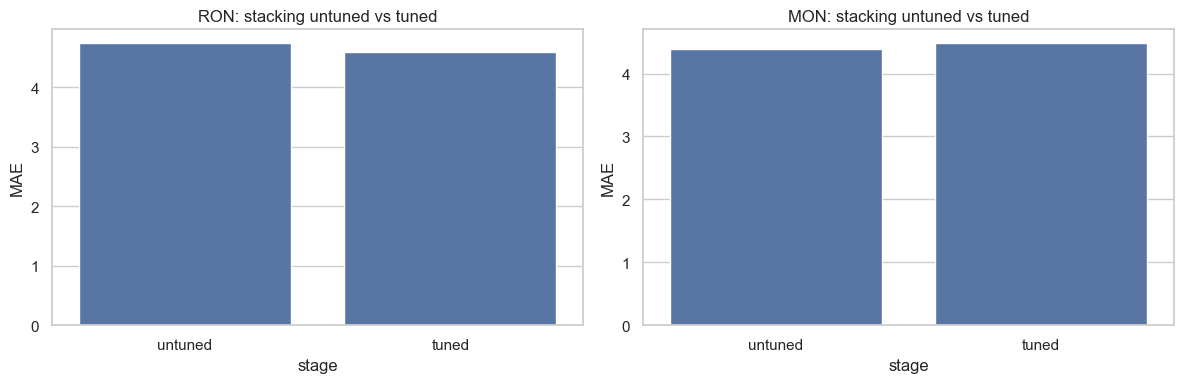

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=ron_optuna_cmp[ron_optuna_cmp["model"] == "Stacking"],
    x="stage",
    y="MAE",
    ax=axes[0],
)
axes[0].set_title("RON: stacking untuned vs tuned")

sns.barplot(
    data=mon_optuna_cmp[mon_optuna_cmp["model"] == "Stacking"],
    x="stage",
    y="MAE",
    ax=axes[1],
)
axes[1].set_title("MON: stacking untuned vs tuned")

plt.tight_layout()
plt.show()

In [30]:
optuna_stacking_summary = (
    optuna_results[optuna_results["model"] == "Stacking"]
    .sort_values(["target", "MAE"], ascending=[True, True])
    .groupby("target", as_index=False)
    .first()[["target", "stage", "MAE", "R2"]]
)
optuna_stacking_summary

,target,stage,MAE,R2
0,MON,untuned,4.388027,0.887014
1,RON,tuned,4.586806,0.910553


In [31]:
for _, row in optuna_stacking_summary.iterrows():
    print(
        f'{row["target"]}: better stacking on test -> {row["stage"]} '
        f'(MAE={row["MAE"]:.3f}, R2={row["R2"]:.3f})'
    )

MON: better stacking on test -> untuned (MAE=4.388, R2=0.887)
RON: better stacking on test -> tuned (MAE=4.587, R2=0.911)


## 12. SHAP-анализ финальных моделей

Финальную интерпретацию строим для лучшей версии `Stacking` по каждому таргету.

Так как финальная модель здесь не дерево, а ансамбль с мета-моделью, используем `SHAP KernelExplainer` на небольшом фоне из train-выборки. Это медленнее, чем tree-specific SHAP, поэтому анализ делаем на подвыборке объектов.

Final RON stacking stage: tuned | features: base+extra+fuelclass


100%|██████████| 20/20 [00:02<00:00,  7.70it/s]


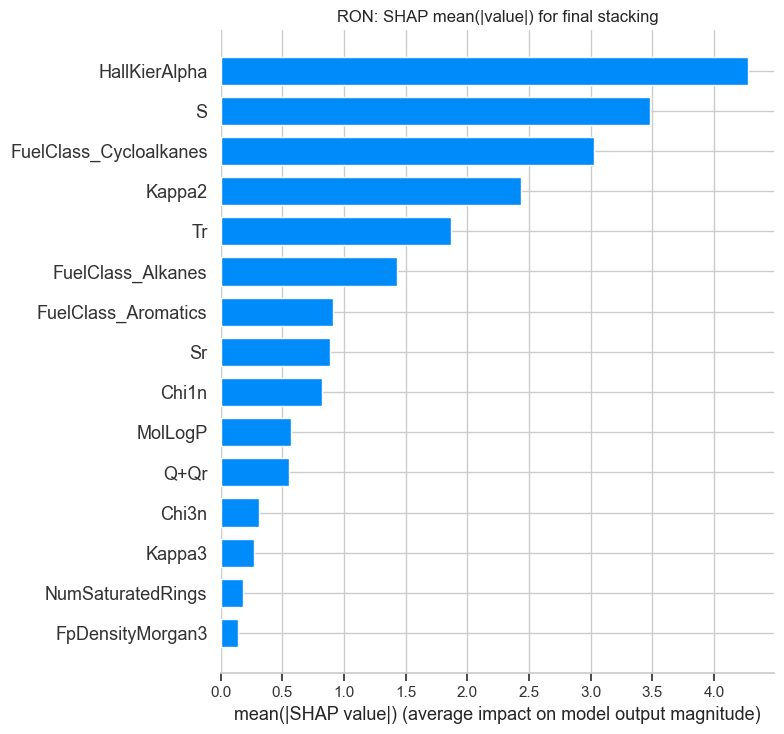

,feature,mean_abs_shap
0,HallKierAlpha,4.272697
1,S,3.481133
2,FuelClass_Cycloalkanes,3.030314
3,Kappa2,2.433835
4,Tr,1.866652
5,FuelClass_Alkanes,1.425540
6,FuelClass_Aromatics,0.907335
7,Sr,0.885510
8,Chi1n,0.816819
9,MolLogP,0.569667


Final MON stacking stage: untuned | features: base+extra+atompair+fuelclass


100%|██████████| 20/20 [00:02<00:00,  7.93it/s]


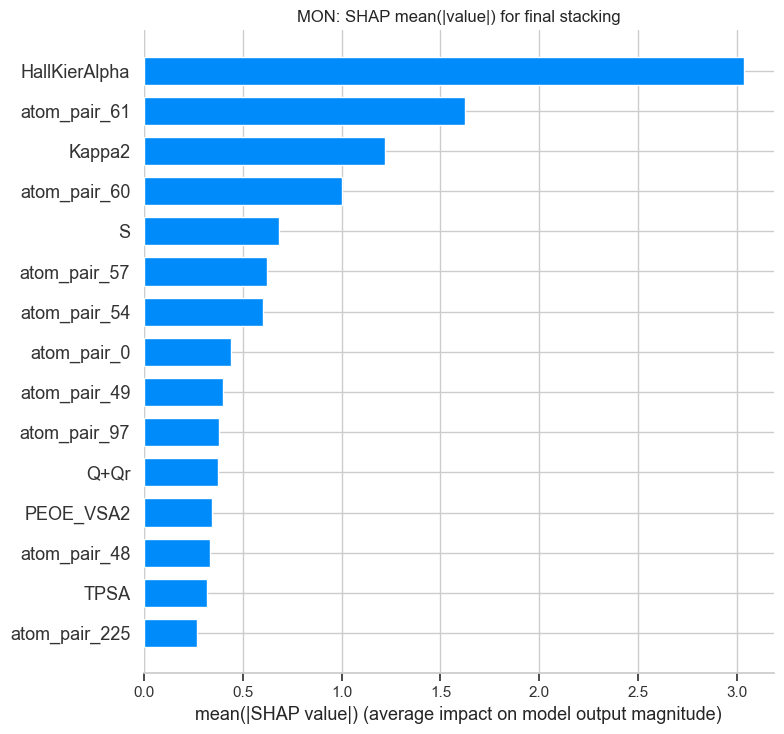

,feature,mean_abs_shap
0,HallKierAlpha,3.033295
1,atom_pair_61,1.624933
2,Kappa2,1.220568
3,atom_pair_60,1.004988
4,S,0.685373
5,atom_pair_57,0.623935
6,atom_pair_54,0.600918
7,atom_pair_0,0.442150
8,atom_pair_49,0.399501
9,atom_pair_97,0.383425


In [32]:
def fit_final_stacking_for_target(target_name: str):
    stacking_rows = optuna_results[
        (optuna_results["target"] == target_name) & (optuna_results["model"] == "Stacking")
    ].sort_values("MAE", ascending=True)
    best_stage = stacking_rows.iloc[0]["stage"]
    feature_name = stacking_rows.iloc[0]["features"]

    X = feature_sets[feature_name].fillna(0)
    y = df_clean[target_name]
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    studies = ron_studies if target_name == "RON" else mon_studies
    if best_stage == "tuned":
        catboost_model = build_optuna_model(optuna.trial.FixedTrial(studies["CatBoost"].best_params), "CatBoost")
        extratrees_model = build_optuna_model(optuna.trial.FixedTrial(studies["ExtraTrees"].best_params), "ExtraTrees")
        lightgbm_model = build_optuna_model(optuna.trial.FixedTrial(studies["LightGBM"].best_params), "LightGBM")
    else:
        catboost_model = build_model("CatBoost")
        extratrees_model = build_model("ExtraTrees")
        lightgbm_model = build_model("LightGBM")

    final_model = StackingRegressor(
        estimators=[
            ("extratrees", extratrees_model),
            ("lightgbm", lightgbm_model),
            ("catboost", catboost_model),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=3,
        n_jobs=1,
    )
    final_model.fit(X_train, y_train)

    return {
        "target": target_name,
        "stage": best_stage,
        "features": feature_name,
        "model": final_model,
        "X_train": X_train,
        "X_test": X_test,
        "y_test": y_test,
    }


def shap_summary_for_final_model(final_info: dict, background_size: int = 30, explain_size: int = 20):
    X_train = final_info["X_train"]
    X_test = final_info["X_test"]
    model = final_info["model"]

    background = shap.sample(X_train, background_size, random_state=RANDOM_STATE)
    explain_df = X_test.iloc[:explain_size].copy()

    explainer = shap.KernelExplainer(model.predict, background)
    shap_values = explainer.shap_values(explain_df, nsamples=100)
    shap_values = np.array(shap_values)

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, explain_df, plot_type="bar", max_display=15, show=False)
    plt.title(f'{final_info["target"]}: SHAP mean(|value|) for final stacking')
    plt.tight_layout()
    plt.show()

    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=explain_df.columns)
    mean_abs_shap = mean_abs_shap.sort_values(ascending=False).head(15).reset_index()
    mean_abs_shap.columns = ["feature", "mean_abs_shap"]
    return mean_abs_shap


final_ron_info = fit_final_stacking_for_target("RON")
final_mon_info = fit_final_stacking_for_target("MON")

print("Final RON stacking stage:", final_ron_info["stage"], "| features:", final_ron_info["features"])
ron_shap_table = shap_summary_for_final_model(final_ron_info)
display(ron_shap_table)

print("Final MON stacking stage:", final_mon_info["stage"], "| features:", final_mon_info["features"])
mon_shap_table = shap_summary_for_final_model(final_mon_info)
display(mon_shap_table)

## 13. Краткие выводы

По итогам этого запуска:

- Для **RON** лучший результат дал **Stacking** на фичсете **`base + extra RDKit + atom pair + FuelClass`**.
- Для **MON** лучший результат на test дал **Stacking** на **`base + FuelClass`**, а лучший stacking-фичсет по train-only CV оказался **`base + extra RDKit + atom pair + FuelClass`**.
- **FuelClass** даёт заметный устойчивый прирост почти для всех сильных деревообразных моделей.
- **Atom pair fingerprint** помогает именно **RON**, но не улучшает **MON**.
- **NuSVR** оказался рабочим конкурентом, но обычно не обгоняет лучшие ансамбли.
- **Extra Trees** стабильно силён и полезен как базовый участник для stacking.
- **LightGBM** в текущей конфигурации уступает `CatBoost`, но его всё равно полезно держать в ансамбле.
- Optuna в конце тюнит только базовые модели на train-only CV; в этом прогоне tuned stacking оказался лучше для RON, а untuned stacking — для MON.
- По сравнению с seminar baseline (`CatBoost`: `RON MAE=6.733, R2=0.818`; `MON MAE=6.985, R2=0.708`) итоговые модели здесь заметно сильнее.